In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")

COMBINED_FEATURES_PATH = PROJECT_ROOT / 'data' / 'combined_features'
TRAIN_PATH = COMBINED_FEATURES_PATH / 'train.parquet'
VAL_PATH = COMBINED_FEATURES_PATH / 'val.parquet'
TEST_PATH = COMBINED_FEATURES_PATH / 'test.parquet'

MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cpu
Project root: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1
Using device: cpu


# KNN Model - on combined features
By combining 64-dimensional textual embeddings with graph-based citation features and initial metadata-derived features, this notebook treats citation prediction as a supervised binary classification task on a mixed feature set.

To ensure code quality and reusability, we use the shared model hierarchy:

- `BaseModel`: an abstract class that defines the common contract for preprocessing, training, prediction, evaluation, and saving.
- `KNNModel`: the concrete KNN implementation. It drops non-feature columns, applies `RobustScaler` using training statistics, and reuses the fitted scaler for validation and test data.


## 1. Load combined feature data

In [2]:
ID_COLUMNS = ["article_id", "ref_id"]
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

print("\nSplit sizes train:", {df_train.shape})
print("\nSplit sizes validation:", {df_val.shape})
print("\nSplit sizes test:", {df_test.shape})


Split sizes train: {(2162534, 299)}

Split sizes validation: {(391242, 299)}

Split sizes test: {(396386, 299)}


## 2. Baseline model

In [ ]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski')
KNN_baseline.train_pipeline(df_train, random_state=RANDOM_STATE)

[KNN_baseline] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
0    0.507
1    0.493
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.8752    0.7148    0.7869      5070
           1     0.7532    0.8951    0.8181      4930

    accuracy                         0.8037     10000
   macro avg     0.8142    0.8050    0.8025     10000
weighted avg     0.8150    0.8037    0.8023     10000



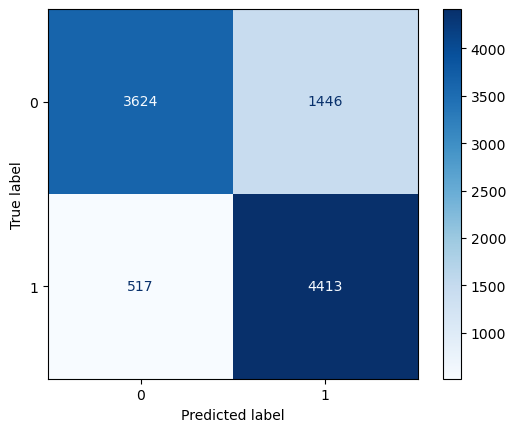

In [4]:
KNN_baseline.test_pipeline(df_test.sample(10000))

> The baseline run is used as a quick sanity check before hyperparameter tuning. Final results should be interpreted from the tuned model evaluation below.


## 3. Hyperparameter tuning
KNN can be computationally expensive on high-dimensional combined feature matrices. To keep tuning feasible, `GridSearchCV` is run on a representative subset of the train and validation data.

The notebook uses `PredefinedSplit` instead of standard K-fold cross-validation. This keeps the validation fold aligned with the project split and avoids leakage from the training set.


In [5]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

[KNN_combined] Grid Search...
[KNN_combined] Preprocessing 2162534 rows...
Label distribution:
is_reference_valid
0    0.500003
1    0.499997
Name: proportion, dtype: float64
[KNN_combined] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64

Starting tuning on 50000 samples...

Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}

Optimal model ready: KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=15)
[KNN_combined] Train model with best params...
[KNN_combined] Preprocessing 2162534 rows...
Label distribution:
is_reference_valid
0    0.500003
1    0.499997
Name: proportion, dtype: float64
[KNN_combined] Starting training...
Selected 2162/2162534
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1113
           1     1.0000    1.0000    1.0000      1049

    accuracy                         1.0000      2162
   macr

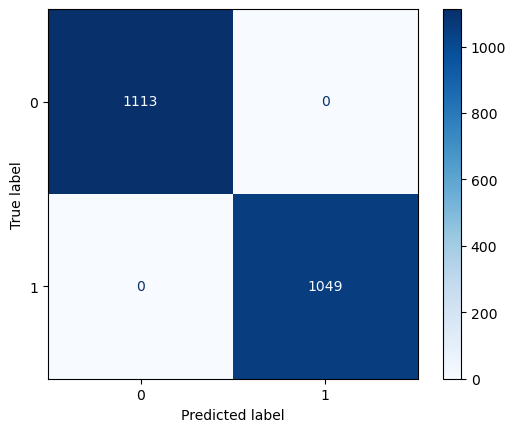

In [7]:
# tuning
KNN_combined = KNNModel("KNN_combined")
KNN_combined.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=N_JOBS,
                               frac=0.001)

## 4. Final model with best parameters
Once the optimal number of neighbors, distance metric, and weighting strategy are selected, the model is retrained on the full training split.

Performance is assessed using:
- Weighted F1-score, to summarize class-balanced performance.
- Confusion matrix, to visualize false positives and false negatives.
- Classification report, with precision, recall, F1-score, and accuracy.


[KNN_combined] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
0    0.503
1    0.497
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.8837    0.7791    0.8281      5030
           1     0.8004    0.8962    0.8456      4970

    accuracy                         0.8373     10000
   macro avg     0.8420    0.8377    0.8368     10000
weighted avg     0.8423    0.8373    0.8368     10000



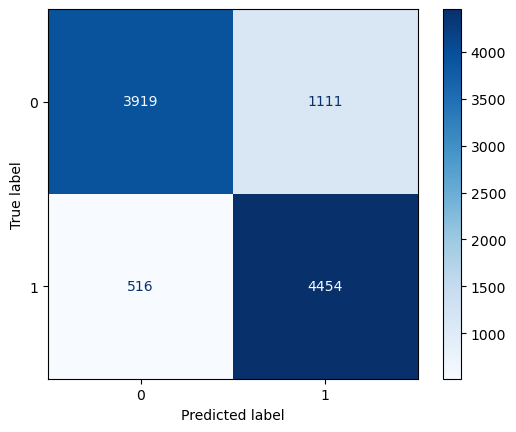

In [8]:
KNN_combined.test_pipeline(df_test.sample(10000))

## 5. Save the pretrained model
Finally, the trained model is saved with the custom `save_model_artifact` utility, so it can be reused for later evaluation, explainability, or deployment experiments.


In [9]:
from utils.model_saver import save_model_artifact
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

save_model_artifact(KNN_combined, df_name='all_features', 
                    model_name="Best_KNN_all_features", 
                    relative_model_dir=MODEL_SAVE_PATH)